# House Prediction Model using Linear regression, ridge and lasso regression

In [5]:
## Housing price dataset
from sklearn.datasets import fetch_california_housing

In [6]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [12]:
data = fetch_california_housing()
data

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [13]:
df = pd.DataFrame(data.data)
df.columns = data.feature_names
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [22]:
df["Price"] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [17]:
## Dividing the data into independent and dependent feature

## Independent features
X = df.iloc[:, : -1]

##dependent feature
y = df.iloc[:, -1]

In [20]:
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [21]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64

In [30]:
## libraries for models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [75]:
## linear regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
ly_pred = linear_model.predict(X_test)
mse = mean_squared_error(y_test, ly_pred)
r2 = r2_score(y_test, ly_pred)

print("Mean Squared error:",mse)
print(f"r2 score: {r2}")

Mean Squared error: 0.5369686543372463
r2 score: 0.597049412878395


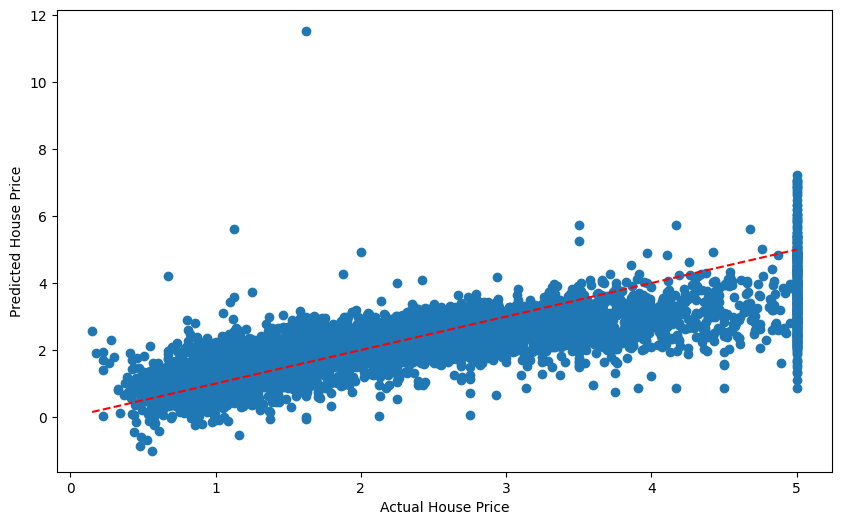

In [76]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, ly_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='red')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.show()

In [77]:
##Ridge
from sklearn.model_selection import GridSearchCV
ridge = Ridge()

params = {"alpha": [1e-15, 1e-10, 1e-4, 0.001, 0.01, 0.1, 1, 2, 3, 5, 10, 20]}
ridge_cv = GridSearchCV(ridge, params, scoring='neg_mean_squared_error', cv=5)
ridge_cv.fit(X_train, y_train)
ry_pred = ridge_cv.predict(X_test)
mse = mean_squared_error(y_test, ry_pred)
r2 = r2_score(y_test, ry_pred)

print("Best alpha:", ridge_cv.best_params_)
print("Mean Squared Error:",mse)
print("Negative Mean Squared Error:", ridge_cv.best_score_)
print("r2 Score:",r2)

Best alpha: {'alpha': 1e-15}
Mean Squared Error: 0.5369686543372463
Negative Mean Squared Error: -0.5230499763383933
r2 Score: 0.5970494128783951


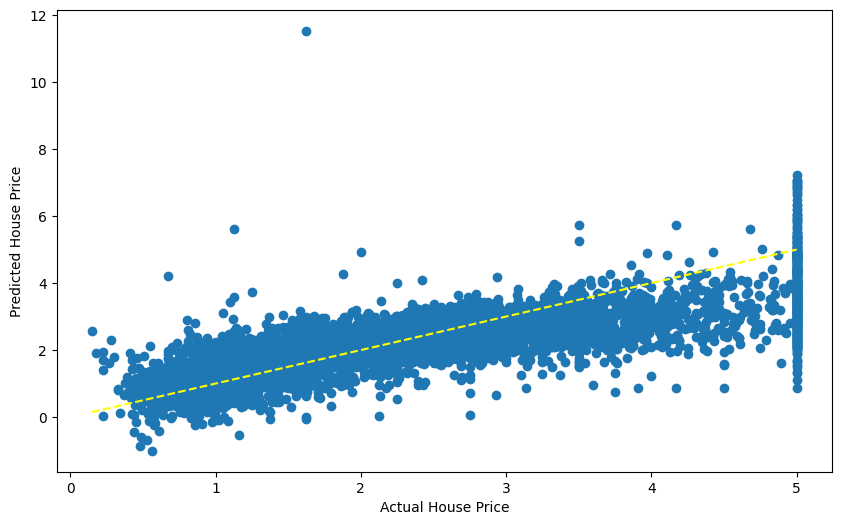

In [78]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, ry_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='yellow')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.show()

In [79]:
## Lasso regression
import warnings
warnings.filterwarnings('ignore')
lasso = Lasso()

params = {"alpha": [1e-15, 1e-10, 1e-4, 0.001, 0.01, 0.1, 1, 2, 3, 5, 10, 20]}
lasso_cv = GridSearchCV(lasso, params, scoring='neg_mean_squared_error', cv=5)
lasso_cv.fit(X_train, y_train)
lsy_pred = lasso_cv.predict(X_test)
mse = mean_squared_error(y_test, lsy_pred)
r2 = r2_score(y_test, lsy_pred)

print("Best alpha:", lasso_cv.best_params_)
print("Mean Squared Error:",mse)
print("Negative Mean Squared Error:", lasso_cv.best_score_)
print("r2 Score:",r2)

Best alpha: {'alpha': 0.0001}
Mean Squared Error: 0.5368504099895516
Negative Mean Squared Error: -0.5230495055503322
r2 Score: 0.5971381454867932


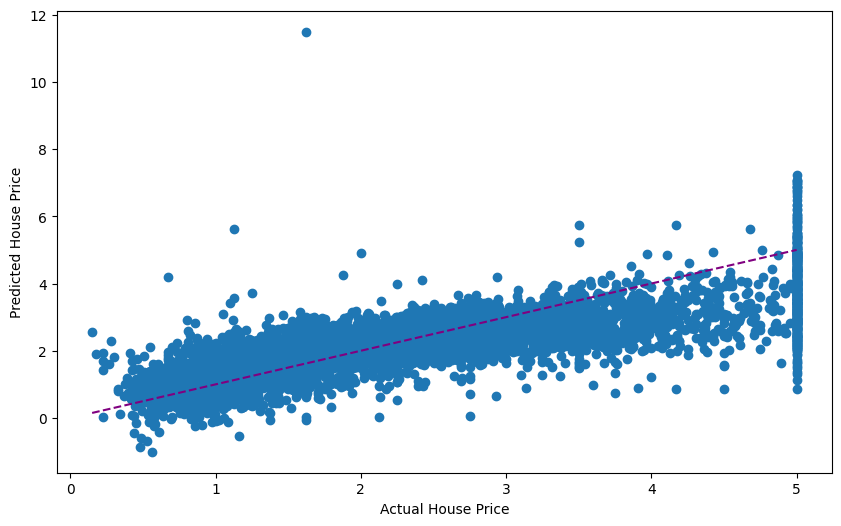

In [80]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, lsy_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--', color='purple')
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.show()

In [82]:
## Comparision of linear, ridge and lasso
comp = pd.DataFrame({
    "Model" : ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2_Score" : [
        r2_score(y_test,ly_pred),
        r2_score(y_test,ry_pred),
        r2_score(y_test,lsy_pred)
    ],
    "MSE": [
        mean_squared_error(y_test,ly_pred),
        mean_squared_error(y_test,ry_pred),
        mean_squared_error(y_test,lsy_pred)
    ]
})
comp

,Model,R2_Score,MSE
0,Linear Regression,0.597049,0.536969
1,Ridge Regression,0.597049,0.536969
2,Lasso Regression,0.597138,0.536850
